Shape Number mínimo: 0.95
Circularidade mínima: 0.85
Objetos detectados: 1


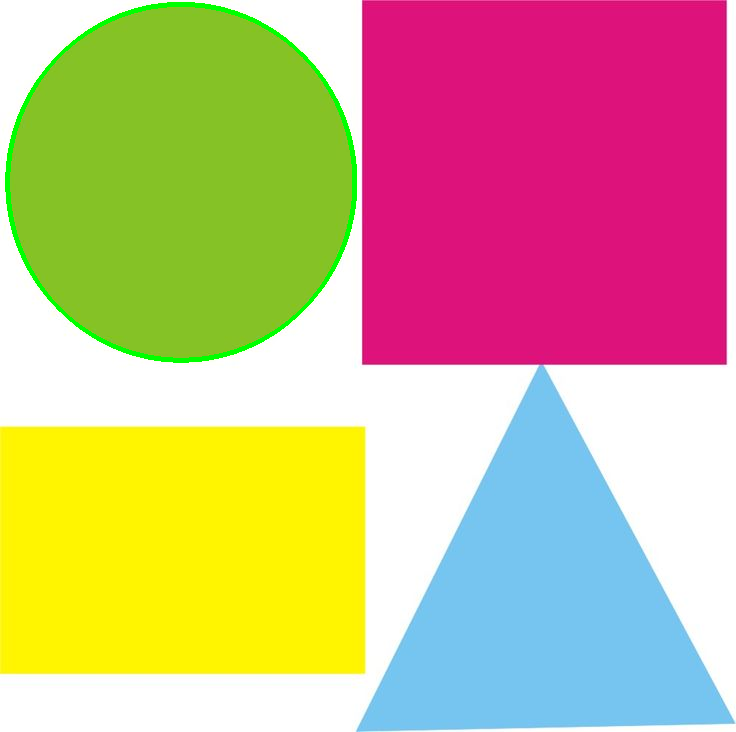

In [4]:
import cv2
import numpy as np
from scipy.ndimage import distance_transform_edt
from google.colab.patches import cv2_imshow

def detect_circles(image_path, shape_threshold=0.95, circularity_threshold=0.85):
    # carrega a imagem
    img = cv2.imread(image_path)
    if img is None:
        print("Erro: Imagem não encontrada.")
        return

    # coloca a imagem em tons de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # pré-processamento da imagem
    blurred = cv2.GaussianBlur(gray, (9, 9), 2) # aplica o filtro da gaussiana (blur)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) # binariza a imagem
    kernel = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2) # aplica erosão

    # encontra contornos
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    circles = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)

        # ignora objetos muito pequenos ou sem perímetro válido
        if area < 100 or perimeter == 0:
            continue

        # calculo do Shape Number
        mask = np.zeros_like(cleaned)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
        object_pixels = np.where(mask == 255)
        N = len(object_pixels[0])
        sum_distances = np.sum(distance_transform_edt(mask)[object_pixels])
        shape_number = (N ** 3) / (9 * np.pi * (sum_distances ** 2))

        # calculo de circularidade
        circularity = (4 * np.pi * area) / (perimeter ** 2)

        # critérios combinados
        if shape_number >= shape_threshold and circularity >= circularity_threshold:
            circles.append(contour)

    result = img.copy()
    cv2.drawContours(result, circles, -1, (0, 255, 0), 3)

    cv2_imshow(result)

# Exemplo de uso (substitua pelo caminho da sua imagem no Colab)
detect_circles("/content/8e5d89958b67620d6a23975a45f6cdd3.jpg")